#Kernal PCA (Kernel Principal Component Analysis)


##Detailed theory

an extension of Principal Component Analysis (PCA) that uses kernel methods to perform non-linear dimensionality reduction

Kernel methods are a class of machine learning algorithms that operate by ***mapping data into a higher-dimensional space***, allowing for the identification of complex patterns and relationships that might not be apparent in the original data


reference: https://graphics.stanford.edu/courses/cs233-25-spring/ReferencedPapers/scholkopf_kernel.pdf

https://www.cs.mcgill.ca/~dprecup/courses/ML/Lectures/ml-lecture13.pdf


stems form the recent discussion, we have the principal of PCA is related to the creation of Covarance matrix

in fact, there are 2 types of Covarance matrix function

One is called ***Sample Covarance***, which is:

$$
C = \frac{1}{n-1}\sum^n_{j=1}(x_j - μ) (x_j - μ)^T =\frac{1}{n-1}\sum^n_{j=1}x_j x^T_j ∈ ℝ^{dxd}
$$

And this is one is called ***Population Covarance***, which is:

$$
C = \frac{1}{n}\sum^n_{j=1}(x_j - μ) (x_j - μ)^T =\frac{1}{n}\sum^n_{j=1}x_j x^T_j ∈ ℝ^{dxd}
$$

and then we find the eigenvectors that have the similar dimension and choose out the highest eigenvalues based on this eigenbasis function:

$$
Av = Cv = λv
$$

With $C$ represents the Covariance Vector

$v$ represents the eigenvectors

$λ$ represents the eigenvalues

$$
z_i = v^T_i, v_2^Tx_i,..., x^T_kx_i
$$

So PCA boils down to eigendecomposition of the covariance matrix.

<h3>Kernel Func</h3>

For kernel PCA, the principal here is merged by the principal of SVM(Support Vector Machines), breakthrough the linear principal of PCA, fails when data lies on a nonlinear manifold.

with:
$$ϕ:Rd→F$$

Like i have discussed before, the kernel principal is mapping the data into a higher-dimensional space.

Just to save time, Kernel PCA is just insert other functions to mends and alter the reduced rows of table or a matrix

thus, instead of the number of rows as: $x_1, x_2,...,x_k$, we just need to insert the function here: $ϕ(x_1), ϕ(x_2),...,ϕ(x_k)$

which turns out, the covariance of kernel PCA--in Population Covariance:

$$
c̅ = \frac{1}{n}\sum^n_{j=1}[ϕ(x_j - μ)] [ϕ(x_j - μ)]^T =\frac{1}{n}\sum^n_{j=1}ϕ(x_j) ϕ(x_j)^T ∈ ℝ^{dxd}
$$

thus, when inserted into the given function:

$$
Cv = λv = c̅v
$$

given the eigenvector to be:

$$
v = \sum^n_{i=1} α_iϕ(x_i)
$$

this is deduced from the assumption that the solution lies in the span of the data in $𝐹$

or it is often called **The Representer Theorem**

is expressing a vector
𝑣
v in a feature space
𝐹
F, where:

$𝜙(𝑥_𝑖)$: the feature map of data point
$𝑥_𝑖$, mapping it into the high-dimensional space $𝐹$
$𝛼𝑖$: scalar coefficients (weights),
$n$: the number of data points.



we have this deduction:
$$
 => \: \: c̅v = λv
$$

to be detailed

$$
\left\{
\begin{aligned}
C = \frac{1}{n} \sum_{j=1}^{n} \phi(x_j)\phi(x_j)^T\\
v = \sum^n_{i=1} α_iϕ(x_i)\\
\end{aligned}
\right.
$$
$$
\frac{1}{n} \sum_{j=1}^{n} \phi(x_j)\phi(x_j)^T v = \lambda v\\
\phi(x_j)^T v = \langle \phi(x_j), v \rangle
$$

$$
\frac{1}{n} \sum_{j=1}^{n} \phi(x_j) \langle \phi(x_j), v \rangle = \lambda v =
\frac{1}{n} \sum_{j=1}^{n} \phi(x_j) \left\langle \phi(x_j), \sum_{i=1}^{n} \alpha_i \phi(x_i) \right\rangle
$$

$$
= \frac{1}{n} \sum_{j=1}^{n} \phi(x_j) \sum_{i=1}^{n} \alpha_i \langle \phi(x_j), \phi(x_i) \rangle
$$

Putting it together, we have:

$$
\frac{1}{n} \sum_{j=1}^{n} \phi(x_j) \sum_{i=1}^{n} \alpha_i \langle \phi(x_j), \phi(x_i) \rangle = \lambda \sum_{i=1}^{n} \alpha_i \phi(x_i)
$$

or:

$$
λ(ϕ(x_k)V) = (ϕ(x_k)c̅V)\:\: for \:\: k = 1,...n
$$

when doing a kernel, we can define a kernel function:

$$
k(x_1,x_2) = ⟨ϕ(x_1), ϕ(x_2)⟩
$$

with k can be anything which is the kernel function. which i can be:

$$
\left\{
\begin{aligned}
linear: \:\:\: k(x_1,x_2) = x_1^Tx_2\\
Polynomial:  \:\:\: (x_1^Tx_2 +c)^d\\
RBF(Radial Basis Function) (Gaussian):  \:\:\:  e^{-\frac{||x_1-x_2||^2}{2σ^2}} = exp(-\frac{||x_1-x_2||^2}{2σ^2}) = exp(-{γ||x_1-x_2||^2}) \:\: (with \:\: γ= \frac{1}{2σ^2})
\end{aligned}
\right.
$$

and then we have the Kernel Matrix

$$
K_{ij} = k(x_i,x_j)= ⟨ϕ(x_i), ϕ(x_j)⟩ = ϕ(x_i)^Tϕ(x_j)
$$

which can be represented as:

$$
K =
\begin{bmatrix}
k(x_1, x_1) & k(x_1, x_2) & \cdots & k(x_1, x_n) \\
k(x_2, x_1) & k(x_2, x_2) & \cdots & k(x_2, x_n) \\
\vdots & \vdots & \ddots & \vdots \\
k(x_n, x_1) & k(x_n, x_2) & \cdots & k(x_n, x_n)
\end{bmatrix}
$$

or, in a more detailed way:

$$
K =
\begin{bmatrix}
\langle \phi(\mathbf{x}_1), \phi(\mathbf{x}_1) \rangle & \langle \phi(\mathbf{x}_1), \phi(\mathbf{x}_2) \rangle & \cdots & \langle \phi(\mathbf{x}_1), \phi(\mathbf{x}_n) \rangle \\
\langle \phi(\mathbf{x}_2), \phi(\mathbf{x}_1) \rangle & \langle \phi(\mathbf{x}_2), \phi(\mathbf{x}_2) \rangle & \cdots & \langle \phi(\mathbf{x}_2), \phi(\mathbf{x}_n) \rangle \\
\vdots & \vdots & \ddots & \vdots \\
\langle \phi(\mathbf{x}_n), \phi(\mathbf{x}_1) \rangle & \langle \phi(\mathbf{x}_n), \phi(\mathbf{x}_2) \rangle & \cdots & \langle \phi(\mathbf{x}_n), \phi(\mathbf{x}_n) \rangle
\end{bmatrix}
$$

---
thus, with $c̅v = λv$ => $K^2α = nλKα$ or $Kα = nλα$ and then, what we do is just solve that


##Centering in Feature Space

Centering in Feature Space

Let:

$ \phi(x_i) \in \mathcal{F} $: feature-mapped point

$ \bar{\phi} = \frac{1}{n} \sum_{i=1}^n \phi(x_i) $: mean in feature space

then basically, the centered inner product is:
$$
K_{c(ij)} = K̃ _{ij} = ⟨ϕ(x_i) - ϕ̅, ϕ(x_j) - ϕ̅⟩
$$

this expands to:

$$
K_{c(ij)} = K̃ _{ij} = ⟨\:⟨ ϕ(x_i), ϕ(x_j) ⟩ - ⟨ ϕ̅, ϕ(x_j) ⟩ - ⟨ ϕ(x_i), ϕ̅ ⟩ + ⟨ ϕ̅, ϕ̅ ⟩\: ⟩
$$

based on:

https://rich-d-wilkinson.github.io/MATH3030/2.4-centering-matrix.html

Let $ K $ be the original kernel matrix.
Define $ H = I_n - \frac{1}{n} 1_n1_n^T $, the centering matrix.

where is $I_n$ is the $n × n$ **identity matrix** abd $1_n$ is an $ n×1 $ column vector of ones.

Then the centered kernel matrix is: $K_c =[I_n - \frac{1}{n} 1_n1_n^T]K[I_n - \frac{1}{n} 1_n1_n^T] $


This is equivalent to:
$$
K_c = K-1_nK - K1_n + 1_nK1_n
$$

##Concluding Explaination

so far, we have:

$$
\left\{
\begin{aligned}
C = \frac{1}{n} \sum_{i=1}^{n} \phi(x_i)\phi(x_i)^T\\
v = \sum^m_{l=1} α_{jl}ϕ(x_l)\\
K_{ij} = K(x_i,x_j) = k(x_i,x_j)= ⟨ϕ(x_i), ϕ(x_j)⟩ = ϕ(x_i)^Tϕ(x_j)\\
\frac{1}{n} \sum_{i=1}^{n} \phi(x_i) \sum_{l=1}^{m} \alpha_{jl} \langle \phi(x_i), \phi(x_l) \rangle = \lambda_j \sum_{l=1}^{m} \alpha_{jl} \phi(x_l)\\
\end{aligned}
\right.
$$

given that: the $$v = \sum^m_{l=1} α_jlϕ(l)$$ is the reduced matrix with $m$ row and $j$ dimension like the original(diffcerence is that the original matrix have $i$ row), we can conclude:

but at this time, we plug the kernel in again

$$
\frac{1}{n} \sum_{i=1}^{n} \phi(x_i) \sum_{l=1}^{m} \alpha_{jl} \langle \phi(x_i), \phi(x_l) \rangle = \lambda_j \sum_{l=1}^{m} \alpha_{jl} \phi(x_l) = \frac{1}{n} \sum_{i=1}^{n} \phi(x_i) \big(\sum_{l=1}^{n} \alpha_{jl} K(x_i,x_l)\: \big)
$$

or we can multiply $ϕ(x_k)^T$, we can have:

$$
\frac{1}{n} \sum_{i=1}^{n} \phi(x_i)ϕ(x_k)^T \big(\sum_{i=1}^{n} \alpha_i K(x_i,x_j)\: \big) = \lambda_j \sum_{i=1}^{n} \alpha_{jl} \phi(x_l)ϕ(x_k)^T
$$

Thus, based on the given info, we plug he kernel in...

$$
\frac{1}{n} \sum_{i=1}^{n} K(x_k,x_i) \big(\sum_{i=1}^{n} \alpha_i K(x_i,x_j)\: \big) = \lambda_j \sum_{i=1}^{n} \alpha_{jl} K(x_k,x_l)
$$

when we reaggreange things:

$$
K^2a_j = nλ_jKa_j \: => \: Kα_j = nλ_jα_j
$$

we also have normalization condition for the $a_j$ vectors:

we have the fundamental idea of $v^Tv = 1$ thus:


$$
v^T_jv_j = 1 = \sum^m_{l=1} α_{jl}ϕ(x_l)^T\sum^m_{k=1} α_{jk}ϕ(x_k) = 1
$$
or:
$$Ka^T_ja_j=1$$ with a serves as the coefficient of the eigenvector

since we have both abbreviated function, we shall plug in:
$$
\left\{
\begin{aligned}
Ka^T_ja_j=1\\
Kα_j = nλ_jα_j
\end{aligned}
\right.
$$
we get: $$nλ_jα_ja_j^T = 1$$

thus, based on that, for any new point of $x$---like a table have a new column:

$$
ϕ(x)^Tv_j = \sum^m_{i=1} α_{ji}ϕ(x)ϕ(x_i)^T = \sum^m_{i=1} α_{ji}K(x,x_i)
$$

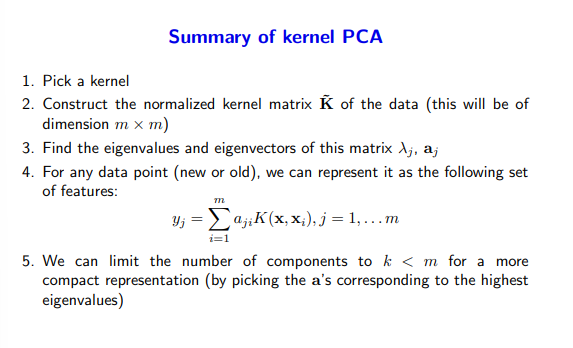

**Summary: Kernel PCA Algorithm**

Given data $x_1, \ldots, x_n$ and a kernel function $k$:

1. Compute the kernel matrix $K \in \mathbb{R}^{n \times n}$ where  
   $$K_{ij} = k(x_i, x_j)$$

2. Center the kernel matrix to get $K_c$
$$
K_c = K-1_nK - K1_n + 1_nK1_n
$$

3. Perform eigendecomposition:  
   $$K_c \alpha = \lambda \alpha$$

4. Normalize eigenvectors (so that $\alpha^T K \alpha = 1$)

5. Project a new data point $x$ onto the principal components:  
   $$
   z = \sum_{i=1}^n \alpha_i k(x_i, x)
   $$


##Coding Example

[[ 0.27883681 -0.04937532]
 [-0.08843833  0.30785654]
 [ 0.90411383  0.43947641]
 [ 0.32805389 -0.16595823]
 [-0.69448822  0.72588676]] 

 [[-0.59474967  0.20870297]
 [ 0.0923348  -0.55869506]
 [-0.016155   -0.0408686 ]
 [-0.46796907  0.32913578]
 [-0.01571595 -0.04261878]] 

 [[ 0.26102383  0.12253848]
 [-0.24508728  0.2022703 ]
 [ 0.48947133  0.88264316]
 [ 0.36850544  0.05574328]
 [-0.98127649  0.19383238]]


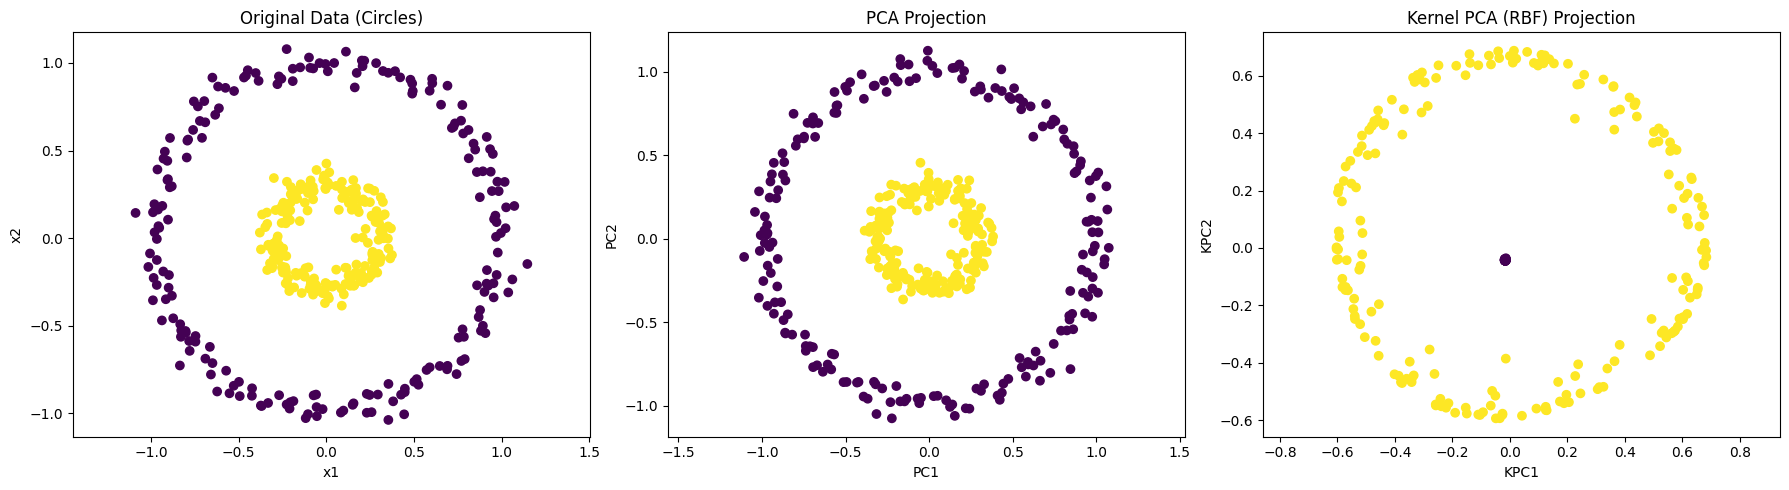

              precision    recall  f1-score   support

           0       0.50      0.50      0.50       200
           1       0.50      0.49      0.50       200

    accuracy                           0.50       400
   macro avg       0.50      0.50      0.50       400
weighted avg       0.50      0.50      0.50       400

              precision    recall  f1-score   support

           0       0.68      1.00      0.81       200
           1       1.00      0.53      0.69       200

    accuracy                           0.76       400
   macro avg       0.84      0.76      0.75       400
weighted avg       0.84      0.76      0.75       400



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_circles
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Generate synthetic nonlinear data (concentric circles)
X, y = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=42)

# Apply standard PCA
#only n_components=2 just to prove the efficacy of kernel
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Apply Kernel PCA with RBF kernel--Radial Basis Function
'''
The RBF kernel (Radial Basis Function), also known as the Gaussian kernel, is
defined mathematically as:

$$K(x_1,x_2) = exp(-γ∥x_1-x_2∥^2)$$

The RBF kernel allows Kernel PCA to project nonlinear data (like circles or
spirals) into a higher-dimensional space where it becomes linearly separable.

This is exactly what you observed in the plot: concentric circles become a
linearly separable shape in the transformed space.
'''
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=15)
X_kpca = kpca.fit_transform(X)

#just to show....
print(X_pca[:5],"\n"*2, X_kpca[:5],"\n"*2, X[:5])

# Plot original data
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.title('Original Data (Circles)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')

# Plot PCA result
plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.title('PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.axis('equal')

# Plot Kernel PCA result
plt.subplot(1, 3, 3)
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='viridis')
plt.title('Kernel PCA (RBF) Projection')
plt.xlabel('KPC1')
plt.ylabel('KPC2')
plt.axis('equal')

plt.tight_layout()
plt.show()

pipeline_PCA = make_pipeline(
    PCA(n_components=2),
    LogisticRegression()
)
y_PCA_prediction = pipeline_PCA.fit(X, y).predict(X)
print(classification_report(y, y_PCA_prediction))

pipeline_KPCA = make_pipeline(
    KernelPCA(n_components=2, kernel='rbf', gamma=15),
    LogisticRegression()
)

y_KPCA_prediction = pipeline_KPCA.fit(X, y).predict(X)
print(classification_report(y, y_KPCA_prediction))

[[ 0.27883681 -0.04937532]
 [-0.08843833  0.30785654]
 [ 0.90411383  0.43947641]
 [ 0.32805389 -0.16595823]
 [-0.69448822  0.72588676]] 

 [[-0.13743221  0.72909289]
 [ 0.12885986 -0.12826812]
 [-0.22809158 -0.17931364]
 [-0.10840159  0.64803528]
 [-0.22581897 -0.19644534]] 

 [[ 0.26102383  0.12253848]
 [-0.24508728  0.2022703 ]
 [ 0.48947133  0.88264316]
 [ 0.36850544  0.05574328]
 [-0.98127649  0.19383238]]


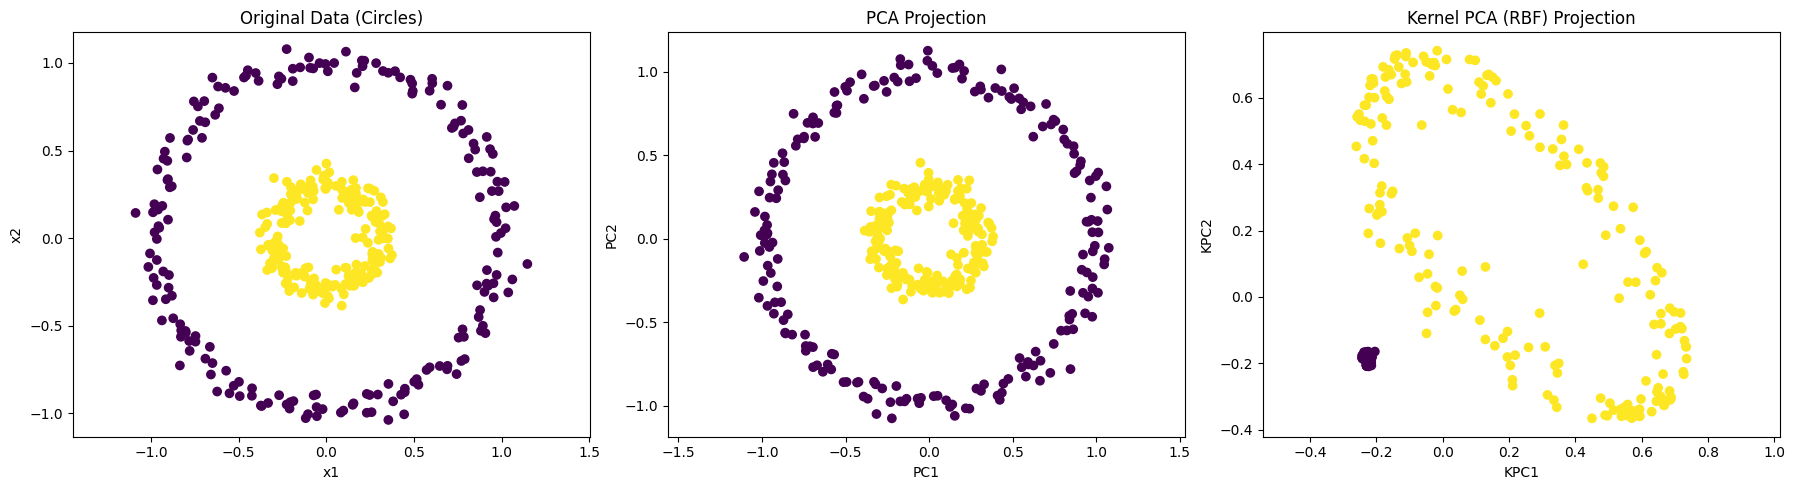

              precision    recall  f1-score   support

           0       0.50      0.50      0.50       200
           1       0.50      0.49      0.50       200

    accuracy                           0.50       400
   macro avg       0.50      0.50      0.50       400
weighted avg       0.50      0.50      0.50       400

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       200
           1       1.00      0.99      0.99       200

    accuracy                           0.99       400
   macro avg       1.00      0.99      0.99       400
weighted avg       1.00      0.99      0.99       400



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_circles
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

# Generate synthetic nonlinear data (concentric circles)
X, y = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=42)

# Apply standard PCA
#only n_components=2 just to prove the efficacy of kernel
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Apply Kernel PCA with RBF kernel--Radial Basis Function
'''
The RBF kernel (Radial Basis Function), also known as the Gaussian kernel, is
defined mathematically as:

$$K(x_1,x_2) = exp(-γ∥x_1-x_2∥^2)$$

The RBF kernel allows Kernel PCA to project nonlinear data (like circles or
spirals) into a higher-dimensional space where it becomes linearly separable.

This is exactly what you observed in the plot: concentric circles become a
linearly separable shape in the transformed space.
'''

gamma = 9.5

kpca = KernelPCA(n_components=2, kernel='rbf', gamma=gamma)
X_kpca = kpca.fit_transform(X)

#just to show....
print(X_pca[:5],"\n"*2, X_kpca[:5],"\n"*2, X[:5])

# Plot original data
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.title('Original Data (Circles)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')

# Plot PCA result
plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.title('PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.axis('equal')

# Plot Kernel PCA result
plt.subplot(1, 3, 3)
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='viridis')
plt.title('Kernel PCA (RBF) Projection')
plt.xlabel('KPC1')
plt.ylabel('KPC2')
plt.axis('equal')

plt.tight_layout()
plt.show()

pipeline_PCA = make_pipeline(
    PCA(n_components=2),
    LogisticRegression()
)
y_PCA_prediction = pipeline_PCA.fit(X, y).predict(X)
print(classification_report(y, y_PCA_prediction))

pipeline_KPCA = make_pipeline(
    KernelPCA(n_components=2, kernel='rbf', gamma=gamma),
    LogisticRegression()
)

y_KPCA_prediction = pipeline_KPCA.fit(X, y).predict(X)
print(classification_report(y, y_KPCA_prediction))

'''
Using a kernel allows to make a non-linear projection. Here, by using an RBF
kernel, we expect that the projection will unfold the dataset while keeping
approximately preserving the relative distances of pairs of data points that
are close to one another in the original space.

We observe such behaviour in the figure on the right: the samples of a given
class are closer to each other than the samples from the opposite class,
untangling both sample sets. Now, we can use a linear classifier to separate
the samples from the two classes.
'''